## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



In [1]:
# @title Ingrese datos
nombre_estudiante = "" # @param {"type":"string"}
carnet = None # @param {"type":"integer"}


## 1) Descripción del problema **[1 pts]**

Una tienda en Colombia necesita desarrollar un programa que calcule la menor cantidad de monedas necesarias para entregar un cambio determinado a un cliente.
La tienda dispone de las siguientes monedas:

monedas = [50, 100, 200, 500, 1000]


## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.
RQFO1 Leer valor ingresado por el usuario para generar el cambio.
RQFO2 Mostrar el valor escogido por el usuario.
RQFO3 Descomponer el valor en la menor cantidad de monedas de cambio.
RQFO4: Mostrar la menor cantidad de monedas para completar el valor ingresado.


RQNFO1 El sistema debe permitir ingresar un valor para mostrar su cambio. 
RQNFO1 El sistema debe confirmar que el valor ingresado sea entero postivo.
RQNFO3 El sistema no debe alterar el valor ingresado por el usuario . 
RQNFO4 El sistema debe mostrar la menor cantidad de monedas en menos de 3 segundos despues de haber ingresado el valor inicial.



## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptación.

Como usuario se debe tener la posibilidad de ingresar un valor para descomponer en la menor cantidad de monedas.
Criterios de Aceptacion: 

El valor debe ser numerico entero positivo.
En caso de ingresar digitos no validos mostrar un mensaje que informe que el valor no es valido.
Retornar al ingreso del valor.

Como usuario el sistema debe descomponer el valor ingresado en la menor cantidad de monedas para completar el mismo valor.
El sistema debe usar los valores de monedas disponibles en la tienda.

Como usuario se debe tener acceso a la descompocision de valores en la menor cantidad de monedas, teniendo encuenta los valores de moneda disponibles en la tienda.
El sistema debe mostrar la cantidad de monedas necesarias para llegar a el valor ingresado 



## 4) Diagramas de flujo **[5 pts]**
Incluye el diagrama que muestre el proceso general

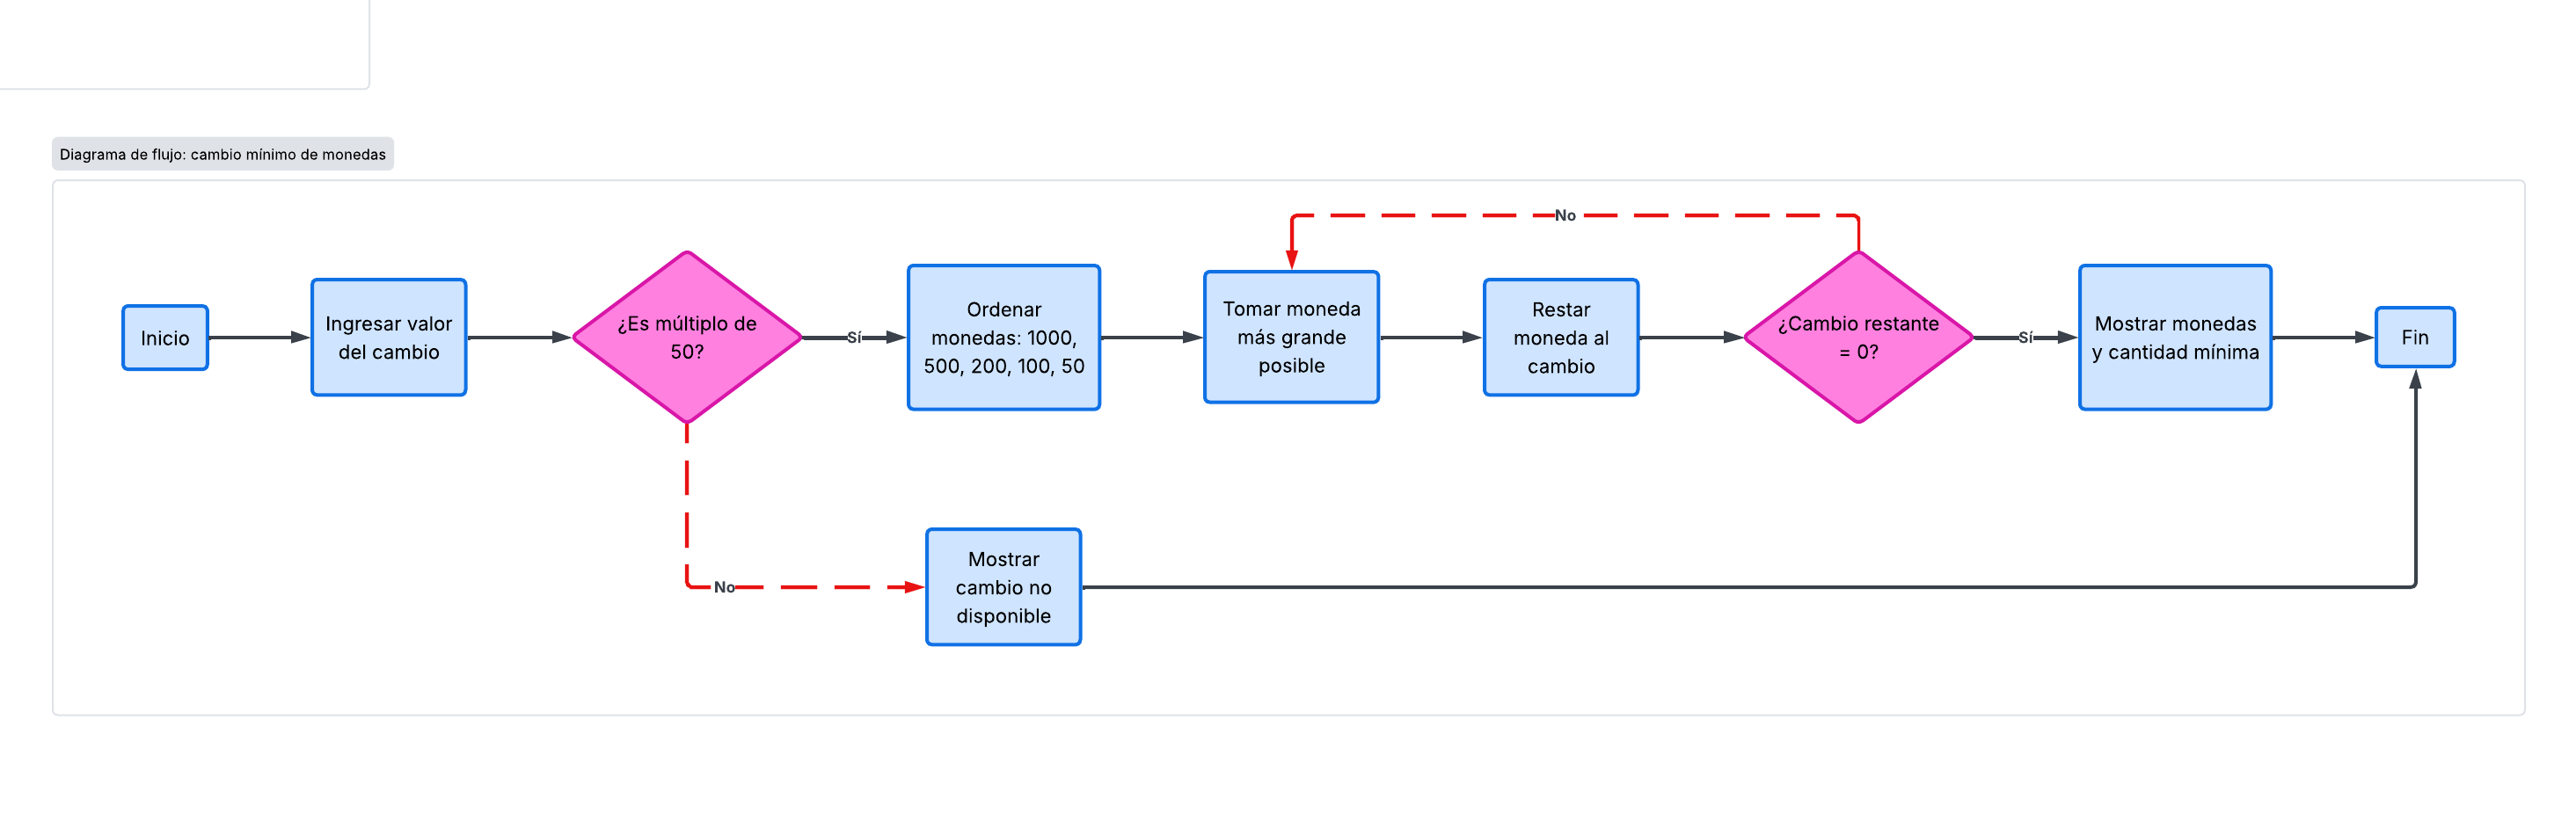


## 5) Diagramas de secuencia **[5 pts]**
Incluye el diagrama que muestre el proceso general

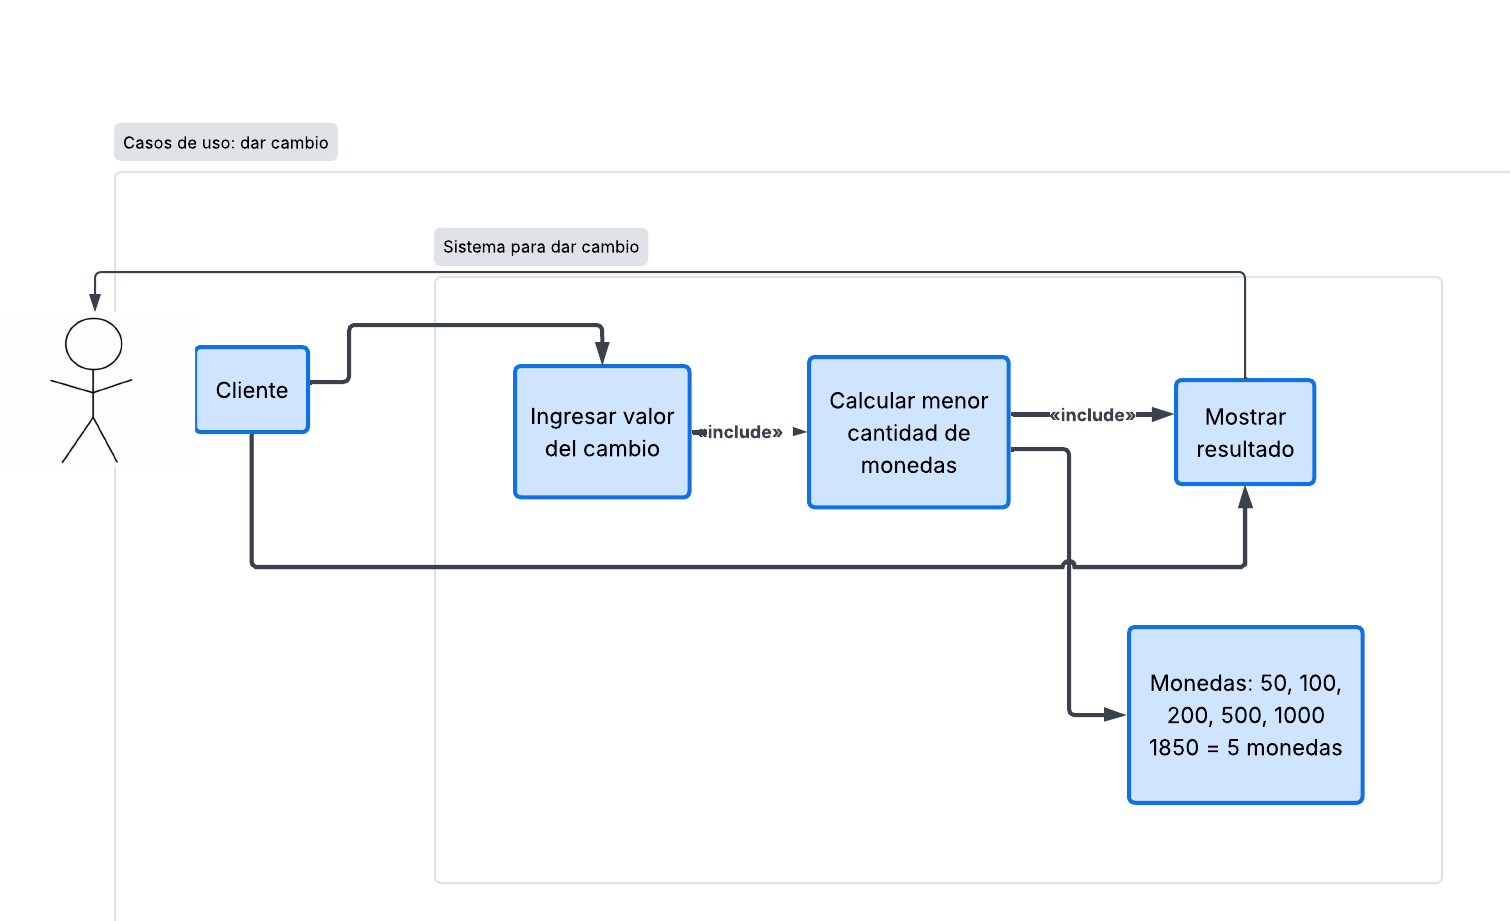


## 6) Diagramas de casos de uso **[5 pts]**
Incluye el diagrama que muestre el proceso general

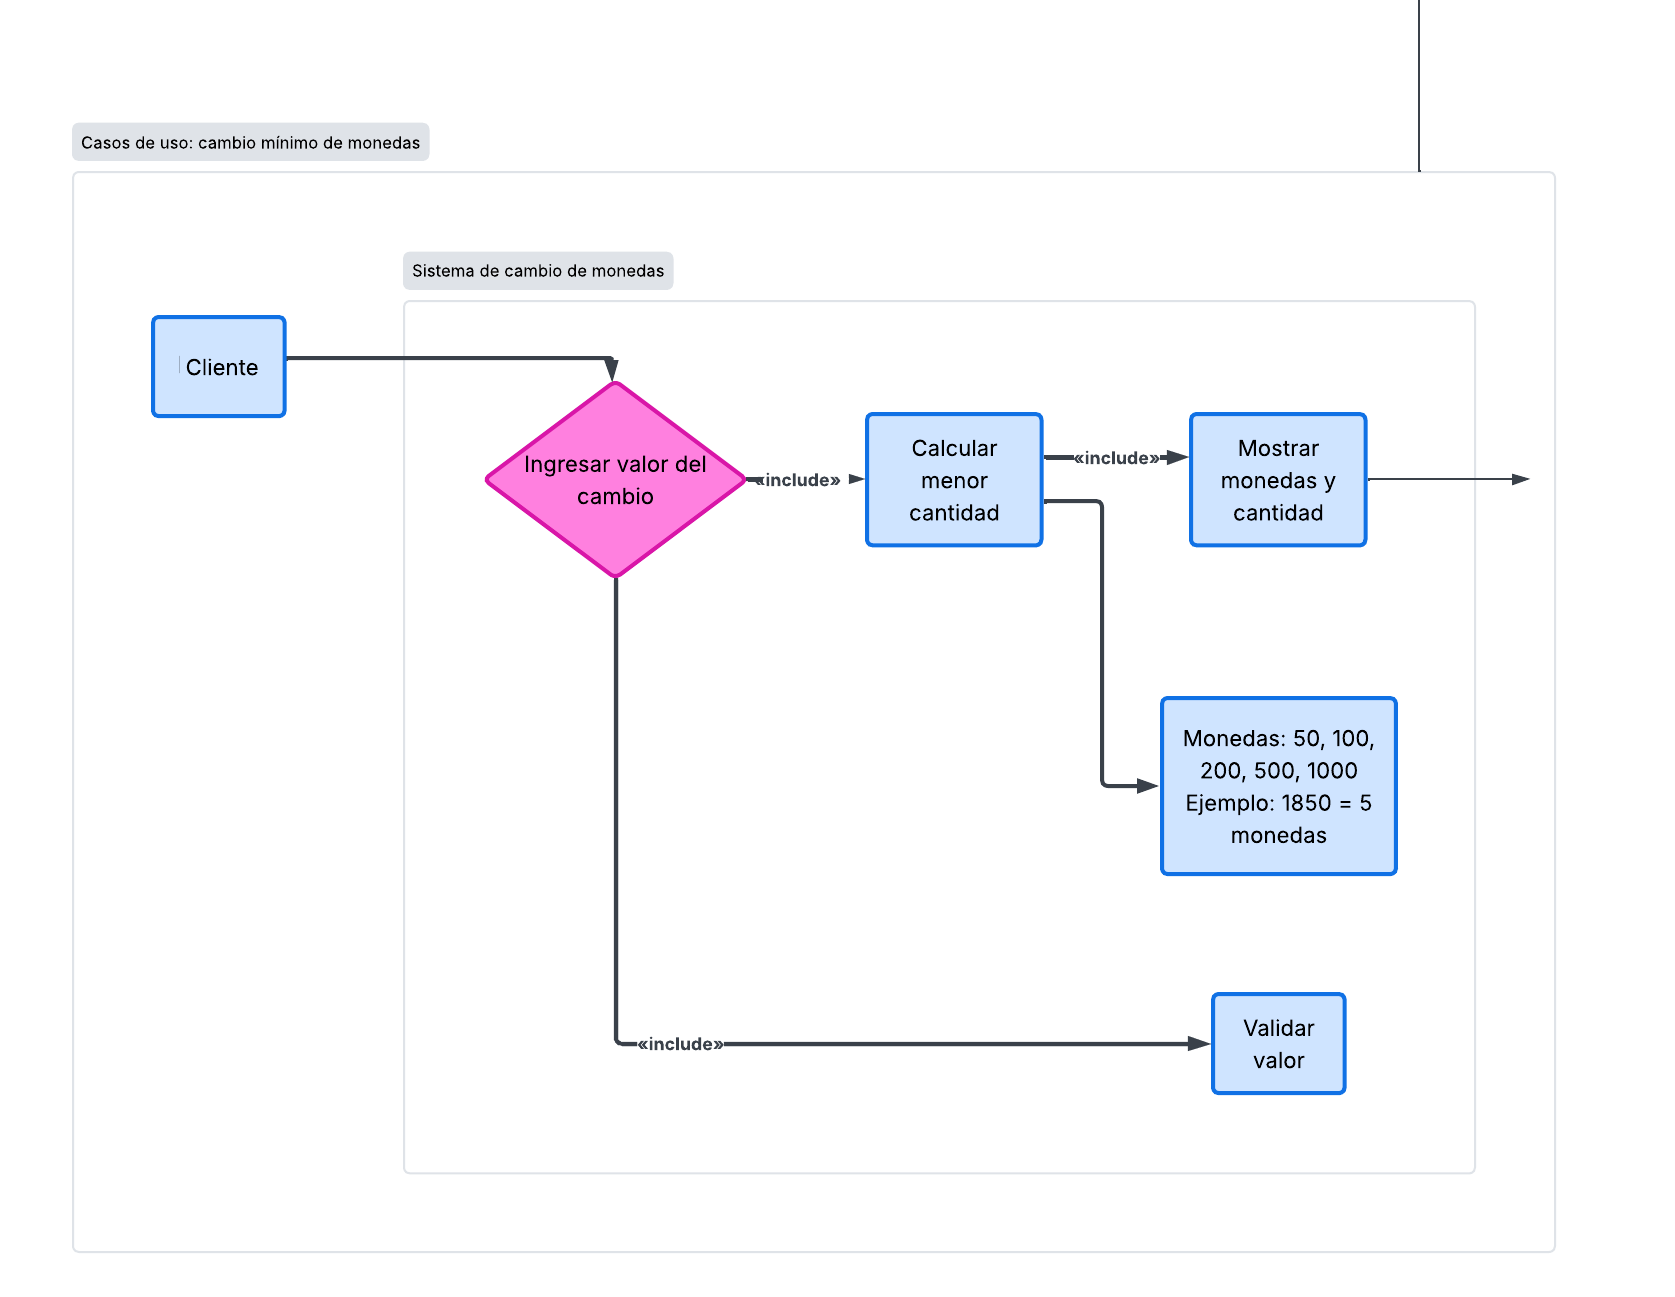


## 7) Análisis de complejidad **[5 pts]**
Incluye:
- Función T[n]
T(n)= t(n-50) +t(n-100) +t(n-200) + t(n-500) +t(n-1000) +O(1)
 
- Mejor y peor caso con gráfica

![alt text](<Multimedia (2)-2.jfif>)

In [2]:
def vueltas_monedas(monedas, vueltas):
    if vueltas == 0:
        return 0
    q = float('inf')
    for moneda in monedas:
        if moneda <= vueltas:
            q = min(q, 1 + vueltas_monedas(monedas, vueltas - moneda))
    return q
def memoized_vueltas(monedas, vueltas):
    r = [float('inf')] * (vueltas + 1)
    r[0] = 0
    for cantidad in range(1, vueltas + 1):
        for moneda in monedas:
            if moneda <= cantidad:
                r[cantidad] = min(r[cantidad], 1 + r[cantidad - moneda])
    return r[vueltas]
monedas = [50, 100, 200, 500, 1000]
try:
    cambio = int(input("Ingrese el valor numérico del cambio: "))
    if cambio <= 0:
        print("Por favor ingrese un valor positivo.")
    else:
        print("El cambio es:", cambio)
        cantidad = memoized_vueltas(monedas, cambio)
        if cantidad == float('inf'):
            print("No es posible entregar el cambio exacto.")
            print("Por favor ingrese otro valor.")
        else:
            print("Cantidad mínima de monedas:", cantidad)
except ValueError:
    print("Por favor ingrese un valor numérico.")


El cambio es: 2000
Cantidad mínima de monedas: 2


## 9) pruebas **[15 pts]**

In [3]:
def test(entrada, expected_output):
    got_output = memoized_vueltas(monedas, int(entrada))
    expected_output = int(expected_output)
    assert got_output == expected_output, \
f"Se obtuvo {got_output}, pero se esperaba {expected_output}"
    print(f"Paso caso de prueba {entrada} -> {expected_output}")


## Pruebas de enunciado

¿Qué va aquí?

Casos de prueba proporcionados por el enunciado.

Entrada usada.

Salida esperada.

Salida obtenida.

In [4]:
valor, salida = "1850", "5"
test(valor, salida)

Paso caso de prueba 1850 -> 5


## Pruebas propias
¿Qué va aquí?

Casos creados por usted.

Casos tomados de [UDebug](https://www.udebug.com/) (si aplica).


In [5]:
input, output = "13500", "14"
test(input , output)

Paso caso de prueba 13500 -> 14


## Pruebas de Desempeño
Qué va aquí?

Medición empírica del tiempo de ejecución.

Gráfica de comportamiento.

Relación entre la gráfica obtenida y el análisis de complejidad teórico.

#### Código base para benchmarking

In [ ]:
# Grafica de desempeño de memoized_vueltas
# Esta celda puede ejecutarse sola o despues de ejecutar todo el notebook.

import time

monedas = [50, 100, 200, 500, 1000]

# Si la funcion no se ejecuto en una celda anterior, la definimos aqui.
if "memoized_vueltas" not in globals():
    def memoized_vueltas(monedas, vueltas):
        r = [float('inf')] * (vueltas + 1)
        r[0] = 0
        for cantidad in range(1, vueltas + 1):
            for moneda in monedas:
                if moneda <= cantidad:
                    r[cantidad] = min(r[cantidad], 1 + r[cantidad - moneda])
        return r[vueltas]


def bench(n=5000, step=50):
    resultados = []

    for valor in range(50, n + 1, step):
        inicio = time.perf_counter()
        memoized_vueltas(monedas, valor)
        fin = time.perf_counter()
        tiempo_ms = (fin - inicio) * 1000
        resultados.append((valor, tiempo_ms))

    return resultados


def dibujar_con_svg(x, y):
    from IPython.display import SVG, display

    ancho, alto = 760, 430
    margen_izq, margen_der = 70, 30
    margen_sup, margen_inf = 35, 60
    w = ancho - margen_izq - margen_der
    h = alto - margen_sup - margen_inf

    max_x = max(x)
    max_y = max(y) if max(y) > 0 else 1

    puntos = []
    for xi, yi in zip(x, y):
        px = margen_izq + (xi / max_x) * w
        py = margen_sup + h - (yi / max_y) * h
        puntos.append(f"{px:.2f},{py:.2f}")

    polyline = " ".join(puntos)
    circles = "".join(
        f'<circle cx="{p.split(",")[0]}" cy="{p.split(",")[1]}" r="2.5" fill="#2563eb"/>'
        for p in puntos[::max(1, len(puntos)//25)]
    )

    svg = f"""
    <svg width="{ancho}" height="{alto}" viewBox="0 0 {ancho} {alto}" xmlns="http://www.w3.org/2000/svg">
      <rect width="100%" height="100%" fill="white"/>
      <line x1="{margen_izq}" y1="{margen_sup}" x2="{margen_izq}" y2="{margen_sup + h}" stroke="black"/>
      <line x1="{margen_izq}" y1="{margen_sup + h}" x2="{margen_izq + w}" y2="{margen_sup + h}" stroke="black"/>
      <polyline points="{polyline}" fill="none" stroke="#2563eb" stroke-width="2"/>
      {circles}
      <text x="{ancho/2}" y="22" text-anchor="middle" font-size="18" font-family="Arial">Tiempo de ejecucion de memoized_vueltas</text>
      <text x="{ancho/2}" y="{alto - 15}" text-anchor="middle" font-size="14" font-family="Arial">Valor del cambio</text>
      <text x="18" y="{alto/2}" text-anchor="middle" font-size="14" font-family="Arial" transform="rotate(-90 18 {alto/2})">Tiempo de ejecucion (ms)</text>
      <text x="{margen_izq}" y="{margen_sup + h + 22}" text-anchor="middle" font-size="12" font-family="Arial">0</text>
      <text x="{margen_izq + w}" y="{margen_sup + h + 22}" text-anchor="middle" font-size="12" font-family="Arial">{max_x}</text>
      <text x="{margen_izq - 10}" y="{margen_sup + 4}" text-anchor="end" font-size="12" font-family="Arial">{max_y:.3f}</text>
    </svg>
    """

    display(SVG(svg))


# Cambia estos valores si quieres una grafica mas grande o mas pequena.
limite = 5000
paso = 50

tiempos = bench(limite, paso)
x = [valor for valor, tiempo in tiempos]
y = [tiempo for valor, tiempo in tiempos]

try:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 5))
    plt.plot(x, y, marker="o", linewidth=2)
    plt.xlabel("Valor del cambio")
    plt.ylabel("Tiempo de ejecucion (ms)")
    plt.title("Tiempo de ejecucion de memoized_vueltas")
    plt.grid(True)
    plt.show()
except ImportError:
    dibujar_con_svg(x, y)
